<a href="https://colab.research.google.com/github/ricvazquez/ColabFiles/blob/main/Sesion12_Evaluacion_Analisis_Descriptivo_273509.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Evaluación — Análisis Descriptivo de Datos

**Entrega individual**

- **Nombre:** Ricardo Vazquez Macias
- **Matrícula:** 273509

Esta evaluación aplica los cuatro bloques de la Sesión 12 (tendencia central, dispersión, forma, visualización) a un dataset que no se trabajó en clase: **NYC Airbnb 2019**, específicamente la columna `price`.

| | |
|---|---|
| **Tiempo estimado** | 45-55 min |
| **Entrega** | Notebook completo (.ipynb) con todas las celdas ejecutadas, subido a Moodle |
| **Puntaje total** | 100 puntos (ver rúbrica al final) |

Cada actividad tiene su propia pregunta de conclusión — esas respuestas se califican como parte de la actividad correspondiente, no concentradas en la reflexión final. Comenta tu código donde tomes una decisión (por ejemplo, cuántos bins usar en un histograma, o qué columna comparar) — el comentario también forma parte del puntaje.

## Preparación

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

url = 'https://raw.githubusercontent.com/pjournal/boun01g-data-mine-r-s/gh-pages/Assignment/AB_NYC_2019.csv'
df = pd.read_csv(url)
df[['name', 'neighbourhood_group', 'room_type', 'price']].head()

,name,neighbourhood_group,room_type,price
0,Clean & quiet apt home by the park,Brooklyn,Private room,149
1,Skylit Midtown Castle,Manhattan,Entire home/apt,225
2,THE VILLAGE OF HARLEM....NEW YORK !,Manhattan,Private room,150
3,Cozy Entire Floor of Brownstone,Brooklyn,Entire home/apt,89
4,Entire Apt: Spacious Studio/Loft by central park,Manhattan,Entire home/apt,80


---
## Actividad 1 — Tendencia central (20 pts)

In [19]:
# 1.1 — Calcula la media, mediana y moda de la columna 'price'.


# primero calculamos la media, modana y moda con funciones de pandas
media = df['price'].mean()
mediana = df['price'].median()
moda = df['price'].mode()

# Imprmimos los resultados
print("Media:", round(media,2))
print("Mediana:", mediana)
print("Moda:", moda)

#Revisamos cuantas veces aparece el minimo o el maximo para ver si esto pudiera afectar a los datos de arriba
countmin = (df['price'] == 0).sum()
countmax = (df['price'] == 10000).sum()
print('Veces que aparece Min:',countmin)
print('Veces que aparece max:',countmax)

Media: 152.72
Mediana: 106.0
Moda: 0    100
Name: price, dtype: int64
Veces que aparece Min: 11
Veces que aparece max: 3


**1.2 — Conclusión (responde aquí en Markdown):**

¿La media y la mediana de `price` se parecen o divergen mucho? Con base en lo que viste en clase sobre `Income`, ¿qué te sugiere esa divergencia (o esa similitud) sobre la presencia de valores extremos en esta columna?

_Tu respuesta:_ La diferencia es muy notoria con la mediana divirgiendo hacia la derecha, esto seguramente es debido a los outliers, los cuales deben de ser pocos datos con tendencias muy altas siendo que la moda es 100, y el maximo el 10,000, deben haber pocos datos altos que hagan que la media se tire mucho para arriba

---
## Actividad 2 — Dispersión (20 pts)

In [29]:
# 2.1 — Calcula el rango, la varianza, la desviación estándar y el IQR (Q1, Q3, IQR) de 'price'.

# Calculamos lo que se nos pide
rango = df['price'].max() - df['price'].min()
varianza = df['price'].var()
std = df['price'].std()
q1 = df['price'].quantile(0.25)
q3 = df['price'].quantile(0.75)
iqr = q3 - q1
max = df['price'].max()
min = df['price'].min()

# Imprimos los diferentes resultados de cada dato
print("Max:",max)
print("Min:", min)
print("Rango:", rango)
print("Varianza:", varianza)
print("Desviación estándar:", std)
print("Q1:", q1)
print("Q3:", q3)
print("IQR:", iqr)


Max: 10000
Min: 0
Rango: 10000
Varianza: 57674.02524696084
Desviación estándar: 240.15416974718727
Q1: 69.0
Q3: 175.0
IQR: 106.0


**2.2 — Conclusión (responde aquí en Markdown):**

Compara el rango contra el IQR de `price`. ¿Cuál de los dos te parece más representativo de la dispersión "típica" de los precios, y por qué? (revisa el valor máximo de la columna antes de responder)

_Tu respuesta:_ El IQR es una representacion mas cercana a la despersion tipica de los datos, ya que el minimo de la columna price, es cero, lo cual provoca que al ommento de obtener el rango solo obtengamos el maximo restado sobre nada, por eso en esta ocasion el IQR es mas acertado

---
## Actividad 3 — Forma (20 pts)

In [30]:
# 3.1 — Calcula la asimetría (skew) y la curtosis (kurt) de 'price'.

# Con la ayuda de las funciones de skew y kurt, calculamos la asimetria y la curtosis
asimetria = df['price'].skew()
curtosis = df['price'].kurt()

# Imprimimos los resultados
print("Asimetria:", asimetria)
print("Curtosis:", curtosis)



Asimetria: 19.118938995046033
Curtosis: 585.6728788988286


**3.2 — Conclusión (responde aquí en Markdown):**

Compara estos valores con los de `Income` que viste en clase (asimetría 6.76, curtosis 159.6 con el outlier incluido). ¿Cómo se comparan los de `price`? ¿Qué relación esperarías entre estos valores y lo que vas a encontrar en la próxima etapa del curso (Datos Atípicos)?

_Tu respuesta:_ Con asimetria podemos ver en que valor se concentran aproximadamente en valores bajos, y con la curtosis, pudieramos separar que la varianza esta sesgada por los valores outliers, como lo pudimos ver (var = 57,674) en el modulo anterior

---
## Actividad 4 — Visualización (30 pts)

<Axes: ylabel='Frequency'>

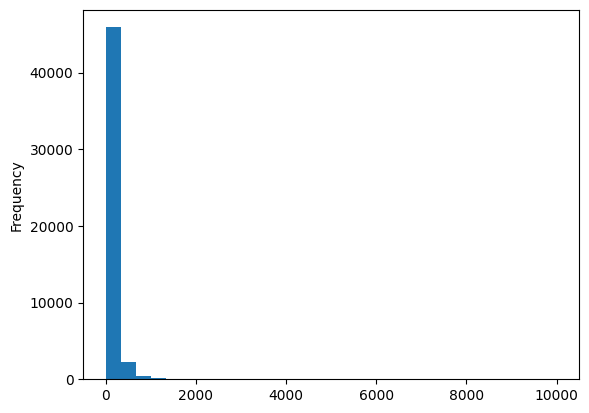

In [37]:
# 4.1 — Construye un histograma de 'price' con .plot(kind='hist').
# Elige un número de bins que te parezca razonable y comenta por qué lo elegiste.

# Hacemos la grafica como nos lo pide la practica, utilizamos un bin de 30 para evitar tanto ruido visual, considerando que los valores
# Se concentran mas en una parte de la grafica posiblemente no necesitemos tanto detalle
df['price'].plot(kind='hist', bins=30)


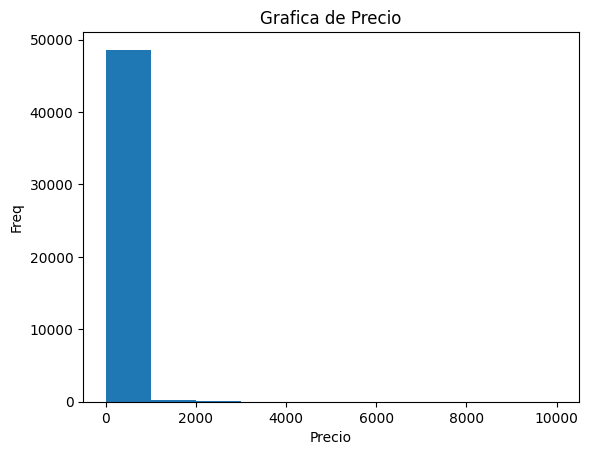

In [38]:
# 4.2 — Construye el mismo histograma con matplotlib.pyplot directamente (plt.hist()),
# agregando título y etiquetas en los ejes.

 # Hacemos la misma grafica
plt.hist(df['price'])
# Y a la grafica le asignamos los titulos para poder visualizar que representa cada uno
plt.xlabel('Precio')
plt.ylabel('Freq')
plt.title('Grafica de Precio')
plt.show()

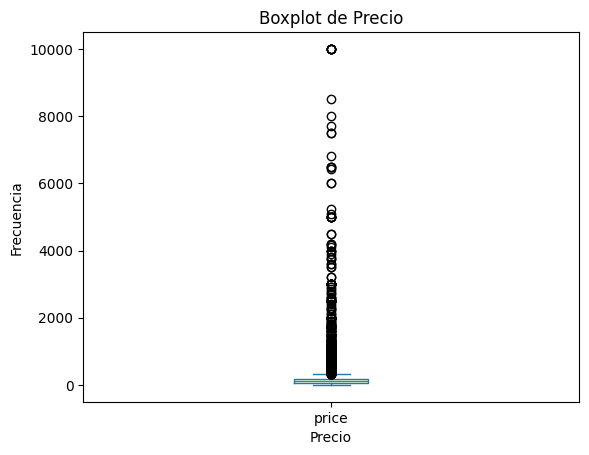

In [26]:
# 4.3 — Construye un boxplot de 'price' (con .plot(kind='box') o plt.boxplot()).

# Con los mismos valores ahora hacemos una grafica de box
df['price'].plot(kind='box')
plt.xlabel('Precio')
plt.ylabel('Frecuencia')
plt.title('Boxplot de Precio')
plt.show()


**4.4 — Conclusión (responde aquí en Markdown):**

Describe lo que observas en el histograma y el boxplot de `price`. ¿Los outliers son visibles en ambos gráficos? ¿En cuál se distinguen mejor? Relaciona tu respuesta con los valores de asimetría y curtosis que calculaste en la Actividad 3.

_Tu respuesta:_ En el grafico hist podemos ver que la frecuencia de los valores debajo de 2 mil es muchisima, lo cual no permite ver los valores que estan arriba de 4 mil lo cual podemos suponer que son muy pocos, pero en el grafico de box se distinguen perfectamente esos pocos valores, y podemos ver como afectan los outliers

---
## Reflexión final (10 pts)

Con base en las 4 actividades anteriores: si tuvieras que explicarle a alguien que no ha visto este dataset por qué el precio "promedio" de $152.72 puede ser engañoso, ¿qué le dirías, usando al menos dos de las medidas que calculaste?

_Tu respuesta:_ Le diria que en lugar de usar la media, se fije mas en la mediana, ya que con los rangos intercuartilicos pudimos ver que este valor es mas acercado a la mediana que a la media. Viendo las graficas pudimos observar el porque con los outliers ubicados arriba de 5 mil, siendo poco frecuentes pero alterando mucho el promedio. Considerando que la asimetria es aproximadamente 19, nos dice que el mayor numero de registros son bajos, pero con una curtosis de arriba de 500, pudieran ser de outliers todos ls valores arriba de esos precios

---
## Rúbrica de evaluación

| Actividad | Puntos | Criterio |
|---|---|---|
| 1. Tendencia central | 20 | Calcula correctamente media, mediana, moda; la conclusión (1.2) conecta la divergencia con la presencia de outliers, no es una afirmación aislada |
| 2. Dispersión | 20 | Calcula correctamente rango, varianza, std, IQR; la conclusión (2.2) justifica cuál medida es más representativa con evidencia del propio cálculo |
| 3. Forma | 20 | Calcula correctamente asimetría y curtosis; la conclusión (3.2) compara explícitamente contra el caso de `Income` visto en clase |
| 4. Visualización | 30 | Histograma y boxplot correctamente construidos (ambas versiones: `.plot()` y `plt.`); código comentado justificando decisiones (ej. bins); la conclusión (4.4) conecta lo visual con los estadísticos de la Actividad 3 |
| Reflexión final | 10 | La explicación usa al menos dos medidas concretas, no es una respuesta genérica |
| **Total** | **100** | |